# Task 2.1 — Dataset Selection and Setup (5 marks)

## Dataset Justification

We use a **synthetic two-cluster, two-view dataset** modelled after **Simulation 1** from Table 1 of the paper. View 1 contains 2-dimensional Gaussian data with different mean vectors per cluster and high intra-view correlation ($\rho = 0.9$). View 2 contains 2-dimensional Beta-distributed data with different shape parameters per cluster (Beta(3,1) vs Beta(1,10)) and moderate intra-view correlation ($\rho = 0.5$). This is a reasonable testbed for the Copula Mixture Model because it captures the paper's central scenario: multi-view data where one view has non-Gaussian (beta) margins that a standard Gaussian mixture would struggle to fit. We generate 200 samples (100 per cluster) with known ground truth labels, which allows direct evaluation via the Adjusted Rand Index. Compared to the paper's original datasets (5360 yeast genes with 4 expression time-points and 6 binding affinity scores), our toy dataset is much smaller and lower-dimensional, but it tests the same core principle — that separating marginal modelling from dependency modelling improves clustering when margins are non-Gaussian.

## Preprocessing

No external data files are needed — the dataset is generated inline using `numpy` and `scipy.stats`. The Beta-distributed view is generated using a Gaussian copula approach to introduce the desired intra-view correlation: we first sample correlated Gaussian variables, then transform them to Beta margins via the CDF transformation. No additional preprocessing (normalisation, missing value handling) is required since the data is synthetic and clean.

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

N = 100  # samples per cluster

# ============================================================
# View 1: 2D Gaussian (per Table 1, Simulation 1)
# ============================================================
# Cluster 1: mean=(0,0), intra-view corr=0.9
# Cluster 2: mean=(1,1), intra-view corr=0.9
rho_x = 0.9
cov_x = np.array([[1, rho_x], [rho_x, 1]])

X1_cluster1 = np.random.multivariate_normal([0, 0], cov_x, N)
X1_cluster2 = np.random.multivariate_normal([1, 1], cov_x, N)
view1 = np.vstack([X1_cluster1, X1_cluster2])

# ============================================================
# View 2: 2D Beta (per Table 1, Simulation 1)
# ============================================================
# Cluster 1: Beta(3,1) for both dims, intra-view corr=0.5
# Cluster 2: Beta(1,10) for both dims, intra-view corr=0.5
# We use a Gaussian copula to generate correlated Beta variates.
rho_y = 0.5
cov_y = np.array([[1, rho_y], [rho_y, 1]])

def generate_correlated_beta(a, b, cov, n):
    """Generate correlated Beta(a,b) samples using a Gaussian copula."""
    Z = np.random.multivariate_normal([0, 0], cov, n)
    U = stats.norm.cdf(Z)  # uniform marginals with Gaussian copula
    return stats.beta.ppf(U, a, b)  # transform to Beta margins

Y_cluster1 = generate_correlated_beta(3, 1, cov_y, N)
Y_cluster2 = generate_correlated_beta(1, 10, cov_y, N)
view2 = np.vstack([Y_cluster1, Y_cluster2])

# Ground truth labels
true_labels = np.array([0]*N + [1]*N)

print(f'View 1 shape: {view1.shape}')
print(f'View 2 shape: {view2.shape}')
print(f'View 1 range: [{view1.min():.3f}, {view1.max():.3f}]')
print(f'View 2 range: [{view2.min():.3f}, {view2.max():.3f}]')
print(f'Labels: {np.bincount(true_labels)}')

View 1 shape: (200, 2)
View 2 shape: (200, 2)
View 1 range: [-1.924, 4.388]
View 2 range: [0.001, 0.998]
Labels: [100 100]


The code above generates our two-view synthetic dataset. View 1 has 2D Gaussian data (unbounded), while View 2 has 2D Beta data (bounded in [0,1]). The `generate_correlated_beta` function uses a Gaussian copula internally to produce correlated Beta variates — this is the same copula mechanism the paper proposes for clustering.

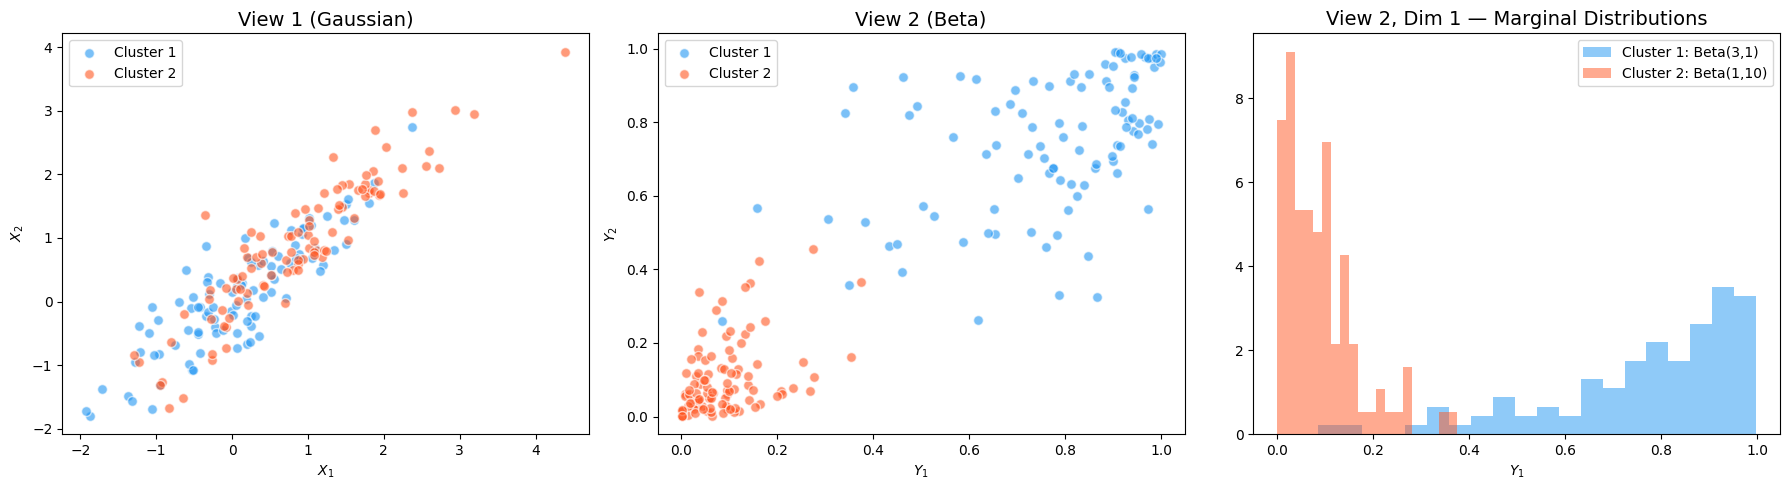

Saved: results/dataset_overview.png


In [2]:
# Visualise the two views with true cluster labels
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#2196F3', '#FF5722']
labels_text = ['Cluster 1', 'Cluster 2']

# View 1
for k in range(2):
    mask = true_labels == k
    axes[0].scatter(view1[mask, 0], view1[mask, 1], c=colors[k], 
                   label=labels_text[k], alpha=0.6, edgecolors='w', s=50)
axes[0].set_title('View 1 (Gaussian)', fontsize=14)
axes[0].set_xlabel('$X_1$')
axes[0].set_ylabel('$X_2$')
axes[0].legend()

# View 2
for k in range(2):
    mask = true_labels == k
    axes[1].scatter(view2[mask, 0], view2[mask, 1], c=colors[k],
                   label=labels_text[k], alpha=0.6, edgecolors='w', s=50)
axes[1].set_title('View 2 (Beta)', fontsize=14)
axes[1].set_xlabel('$Y_1$')
axes[1].set_ylabel('$Y_2$')
axes[1].legend()

# Marginal distributions of View 2
axes[2].hist(view2[true_labels==0, 0], bins=20, alpha=0.5, color=colors[0],
             label='Cluster 1: Beta(3,1)', density=True)
axes[2].hist(view2[true_labels==1, 0], bins=20, alpha=0.5, color=colors[1],
             label='Cluster 2: Beta(1,10)', density=True)
axes[2].set_title('View 2, Dim 1 — Marginal Distributions', fontsize=14)
axes[2].set_xlabel('$Y_1$')
axes[2].legend()

plt.tight_layout()
plt.savefig('results/dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/dataset_overview.png')

The scatter plots above show the two views of our synthetic data, colour-coded by true cluster labels. View 1 (Gaussian) shows two overlapping but separable Gaussian clusters. View 2 (Beta) shows highly non-Gaussian shapes: Cluster 1 is right-skewed (Beta(3,1)) and Cluster 2 is strongly left-skewed (Beta(1,10)). The histograms confirm how different the marginal distributions are from Gaussian — this is exactly the scenario where the copula mixture model should outperform a standard Gaussian mixture.